In [3]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Chargement des données (Chemin Kaggle)
df = pd.read_csv('/kaggle/input/datasets/reddadchaouay/wineqt/WineQT.csv')

# 2. Préparation des Features (X) et de la Target (y)
X = df.drop(['quality', 'Id'], axis=1).values 
# Binarisation : 1 si qualité >= 7 (Bon), 0 sinon (Moyen/Mauvais)
y = np.where(df['quality'].values >= 7, 1, 0)
num_classes = 2
input_dim = X.shape[1]

# 3. Séparation (Train 70%, Val 15%, Test 15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

# 4. Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 5. Configuration GPU et création des Tenseurs
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# 6. DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

Device utilisé : cuda:0


In [4]:
# Version A : Avec nn.Sequential (Simple mais rigide)
mlp_sequential = nn.Sequential(
    nn.Linear(input_dim, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, num_classes)
).to(device)

# Version B : Classe personnalisée (Plus flexible, on ajoute BatchNorm et Dropout)
class CustomMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.hidden1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128) # Stabilise l'apprentissage
        self.drop = nn.Dropout(0.3)    # Désactive 30% des neurones (Anti-surapprentissage)
        self.hidden2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, num_classes)

    def forward(self, x):
        h1 = self.drop(F.relu(self.bn1(self.hidden1(x))))
        h2 = F.relu(self.hidden2(h1))
        return self.out(h2)

mlp_custom = CustomMLP(input_dim, num_classes).to(device)

# Inspection des paramètres exigée par l'EMSI
print("\n--- Inspection avec named_parameters() ---")
for name, param in mlp_custom.named_parameters():
    if param.requires_grad:
        print(f"Nom: {name:15s} | Dimensions: {param.shape}")


--- Inspection avec named_parameters() ---
Nom: hidden1.weight  | Dimensions: torch.Size([128, 11])
Nom: hidden1.bias    | Dimensions: torch.Size([128])
Nom: bn1.weight      | Dimensions: torch.Size([128])
Nom: bn1.bias        | Dimensions: torch.Size([128])
Nom: hidden2.weight  | Dimensions: torch.Size([64, 128])
Nom: hidden2.bias    | Dimensions: torch.Size([64])
Nom: out.weight      | Dimensions: torch.Size([2, 64])
Nom: out.bias        | Dimensions: torch.Size([2])


In [5]:
# ==========================================
# Étape 3 : Stratégies d'initialisation
# ==========================================

# 1. Initialisation Gaussienne (Normale)
def init_normal(module):
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0, std=0.01)
        nn.init.zeros_(module.bias)

# 2. Initialisation Constante (Mauvaise en pratique, mais exigée par le sujet)
def init_constant(module):
    if isinstance(module, nn.Linear):
        nn.init.constant_(module.weight, 1.0) 
        nn.init.zeros_(module.bias)

# 3. Initialisation de Xavier (Glorot) - La plus recommandée ici
def init_xavier(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

# Application de l'initialisation Xavier à notre modèle personnalisé
mlp_custom.apply(init_xavier)
print("Modèle 'mlp_custom' initialisé avec succès avec la méthode Xavier !")

Modèle 'mlp_custom' initialisé avec succès avec la méthode Xavier !


--- Début de l'entraînement ---
Époque [10/50] - Loss de validation : 0.3695
Époque [20/50] - Loss de validation : 0.3678
Époque [30/50] - Loss de validation : 0.3688
Époque [40/50] - Loss de validation : 0.3707
Époque [50/50] - Loss de validation : 0.3788

--- Résultats Finaux sur l'ensemble de Test ---
Accuracy  : 0.8837
Precision : 0.8627
Recall    : 0.8837
F1-Score  : 0.8674


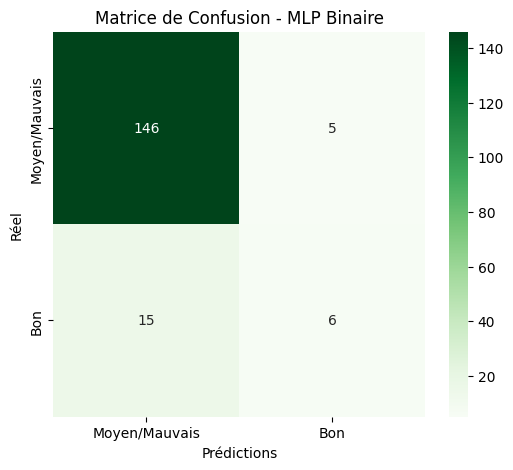

In [6]:
# ==========================================
# Étape 4 : Entraînement et Évaluation
# ==========================================

criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(mlp_custom.parameters(), lr=0.001)

epochs = 50
best_val_loss = float('inf')
best_model_path = "meilleur_mlp_binaire.params"

print("--- Début de l'entraînement ---")
for epoch in range(epochs):
    # Phase d'entraînement
    mlp_custom.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = mlp_custom(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
    # Phase de validation
    mlp_custom.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = mlp_custom(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            
    val_loss /= len(val_loader)
    
    # Sauvegarde du meilleur modèle (Early Stopping)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(mlp_custom.state_dict(), best_model_path)
        
    # Affichage de l'évolution toutes les 10 époques
    if (epoch + 1) % 10 == 0:
        print(f"Époque [{epoch+1}/{epochs}] - Loss de validation : {val_loss:.4f}")

# --- Évaluation Finale sur le Test Set ---
mlp_custom.load_state_dict(torch.load(best_model_path)) # On recharge le meilleur modèle
mlp_custom.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = mlp_custom(batch_X)
        _, preds = torch.max(outputs, 1) 
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

print("\n--- Résultats Finaux sur l'ensemble de Test ---")
print(f"Accuracy  : {accuracy_score(all_targets, all_preds):.4f}")
print(f"Precision : {precision_score(all_targets, all_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall    : {recall_score(all_targets, all_preds, average='weighted', zero_division=0):.4f}")
print(f"F1-Score  : {f1_score(all_targets, all_preds, average='weighted', zero_division=0):.4f}")

# Matrice de confusion
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Moyen/Mauvais', 'Bon'], yticklabels=['Moyen/Mauvais', 'Bon'])
plt.xlabel('Prédictions')
plt.ylabel('Réel')
plt.title('Matrice de Confusion - MLP Binaire')
plt.show()

**Partie 2 : CNN**

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 277kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.4MB/s]



--- Dataset Fashion-MNIST chargé ! ---


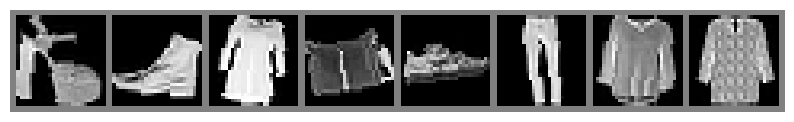

Sandale    | Bottine    | Pull       | Sac        | Baskets    | Pantalon   | Chemise    | Chemise   


In [10]:
# ==========================================
# PARTIE II - Étape 1 : Fashion-MNIST
# ==========================================
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Augmentation et Normalisation (Adapté pour 1 canal : Niveaux de gris)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(10),     
    transforms.ToTensor(),             
    transforms.Normalize((0.5,), (0.5,)) # Seulement 1 valeur car 1 seul canal
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

batch_size = 64

# 2. Téléchargement de Fashion-MNIST
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

# Les 10 classes de vêtements
classes = ('T-shirt', 'Pantalon', 'Pull', 'Robe', 'Manteau', 'Sandale', 'Chemise', 'Baskets', 'Sac', 'Bottine')

# 3. Fonction d'affichage adaptée pour le Noir & Blanc
def imshow(img):
    img = img / 2 + 0.5     # Dé-normalisation
    npimg = img.numpy()
    plt.figure(figsize=(10, 3))
    # On affiche le premier canal en niveaux de gris
    plt.imshow(npimg[0], cmap='gray') 
    plt.axis('off')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

print("\n--- Dataset Fashion-MNIST chargé ! ---")
imshow(torchvision.utils.make_grid(images[:8]))
print(' | '.join(f'{classes[labels[j]]:10s}' for j in range(8)))

In [12]:
# ==========================================
# PARTIE II - Étape 3 (Bonus) : Fine-Tuning de ResNet18 (> 85% Accuracy)
# ==========================================
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch

print("Téléchargement de ResNet18 pour le Fine-Tuning...")
# Chargement des poids pré-entraînés
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 1. LA MAGIE EST ICI : On NE GÈLE PAS les paramètres !
# On supprime la boucle "requires_grad = False" pour laisser tout le réseau apprendre.

# 2. Modifier la dernière couche (Tête de classification)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 10) 

# Transfert sur le GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resnet = resnet.to(device)

# 3. Paramètres d'entraînement
criterion_tl = nn.CrossEntropyLoss()

# 4. LE DEUXIÈME SECRET : Un Learning Rate très faible (0.0001 au lieu de 0.001)
# On optimise TOUT le réseau (resnet.parameters()), mais tout doucement pour ne pas 
# "casser" les connaissances préalables de ResNet.
optimizer_tl = optim.Adam(resnet.parameters(), lr=0.0001)

epochs_tl = 5 # Le GPU va travailler un peu plus dur à chaque époque !
print("\n--- Début de l'entraînement en mode Fine-Tuning ---")

for epoch in range(epochs_tl):
    resnet.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        
        # --- L'ASTUCE POUR FASHION-MNIST (Maintenue) ---
        inputs = inputs.repeat(1, 3, 1, 1)

        optimizer_tl.zero_grad()
        outputs = resnet(inputs)
        loss = criterion_tl(outputs, labels)
        loss.backward()
        optimizer_tl.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100 * correct / total
    
    print(f"Époque [{epoch+1}/{epochs_tl}] - Loss: {epoch_loss:.4f} - Accuracy Train: {epoch_acc:.2f}%")

print("Entraînement Fine-Tuning terminé !")

Téléchargement de ResNet18 pour le Fine-Tuning...

--- Début de l'entraînement en mode Fine-Tuning ---
Époque [1/5] - Loss: 0.4837 - Accuracy Train: 82.53%
Époque [2/5] - Loss: 0.3168 - Accuracy Train: 88.42%
Époque [3/5] - Loss: 0.2775 - Accuracy Train: 89.63%
Époque [4/5] - Loss: 0.2572 - Accuracy Train: 90.40%
Époque [5/5] - Loss: 0.2412 - Accuracy Train: 91.16%
Entraînement Fine-Tuning terminé !


**Partie 3 : LSTM**

In [13]:
# ==========================================
# PARTIE III - Étape 1 : Préparation NLP (Seq2Seq)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device NLP : {device}")

# 1. Définition des Tokens spéciaux
SOS_token = 0 # Start Of Sentence
EOS_token = 1 # End Of Sentence

# 2. Classe pour gérer les dictionnaires de mots (Vocabulaire)
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "<SOS>", 1: "<EOS>"}
        self.n_words = 2  # On compte déjà SOS et EOS

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

# 3. Mini-dataset bilingue (Français -> Anglais)
pairs = [
    ["je suis un etudiant", "i am a student"],
    ["il est tres fort", "he is very strong"],
    ["nous aimons le deep learning", "we love deep learning"],
    ["le reseau de neurones apprend", "the neural network learns"],
    ["tu es en retard", "you are late"],
    ["c est un bon vin", "it is a good wine"] # Petit clin d'oeil à la Partie I !
]

# 4. Initialisation des langues
input_lang = Lang('fr')
output_lang = Lang('en')

for pair in pairs:
    input_lang.addSentence(pair[0])
    output_lang.addSentence(pair[1])

print(f"Mots uniques en Français : {input_lang.n_words}")
print(f"Mots uniques en Anglais  : {output_lang.n_words}")

# 5. Fonction pour transformer une phrase en Tenseur PyTorch
def tensorFromSentence(lang, sentence):
    indexes = [lang.word2index[word] for word in sentence.split(' ')]
    indexes.append(EOS_token) # On ajoute le token de fin à la fin de chaque phrase
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

# Test sur une phrase
test_pair = pairs[0]
tensors = tensorsFromPair(test_pair)
print(f"\nPhrase d'origine : '{test_pair[0]}'")
print(f"Tenseur d'entrée généré :\n{tensors[0]}")

Device NLP : cuda
Mots uniques en Français : 26
Mots uniques en Anglais  : 24

Phrase d'origine : 'je suis un etudiant'
Tenseur d'entrée généré :
tensor([[2],
        [3],
        [4],
        [5],
        [1]], device='cuda:0')


In [14]:
# ==========================================
# PARTIE III - Étape 2 : Encodeur & Décodeur (LSTM / GRU)
# ==========================================
import torch.nn.functional as F

# 1. L'Encodeur (Lit la phrase source et la compresse en un vecteur de contexte)
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, rnn_type='LSTM'):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn_type = rnn_type
        
        self.embedding = nn.Embedding(input_size, hidden_size)
        
        # Le choix dynamique demandé par ton projet !
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(hidden_size, hidden_size)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(hidden_size, hidden_size)
        else:
            self.rnn = nn.RNN(hidden_size, hidden_size)

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.rnn(embedded, hidden)
        return output, hidden

    def initHidden(self):
        # Attention : Le LSTM a besoin de (Hidden state, Cell state). Le GRU n'a que le Hidden state.
        if self.rnn_type == 'LSTM':
            return (torch.zeros(1, 1, self.hidden_size, device=device),
                    torch.zeros(1, 1, self.hidden_size, device=device))
        else:
            return torch.zeros(1, 1, self.hidden_size, device=device)

# 2. Le Décodeur (Prend le contexte et génère la traduction mot par mot)
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, rnn_type='LSTM'):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn_type = rnn_type

        self.embedding = nn.Embedding(output_size, hidden_size)
        
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(hidden_size, hidden_size)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(hidden_size, hidden_size)
        else:
            self.rnn = nn.RNN(hidden_size, hidden_size)
            
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        output = self.embedding(input).view(1, 1, -1)
        output = F.relu(output)
        output, hidden = self.rnn(output, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden

# 3. Instanciation des modèles sur le GPU
hidden_size = 256
# 💡 C'est ICI que tu pourras passer de 'LSTM' à 'GRU' pour tes comparaisons !
choix_architecture = 'LSTM' 

encoder = EncoderRNN(input_lang.n_words, hidden_size, rnn_type=choix_architecture).to(device)
decoder = DecoderRNN(hidden_size, output_lang.n_words, rnn_type=choix_architecture).to(device)

print(f"--- Modèles Encodeur/Décodeur instanciés avec l'architecture : {choix_architecture} ---")
print("\nStructure de l'Encodeur :")
print(encoder)

--- Modèles Encodeur/Décodeur instanciés avec l'architecture : LSTM ---

Structure de l'Encodeur :
EncoderRNN(
  (embedding): Embedding(26, 256)
  (rnn): LSTM(256, 256)
)


In [15]:
# ==========================================
# PARTIE III - Étape 3 : Entraînement et Évaluation
# ==========================================
import torch.optim as optim

# 1. Paramètres d'entraînement
learning_rate = 0.01
# On utilise SGD (Descente de Gradient Stochastique) classique pour ce mini-dataset
encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
criterion = nn.NLLLoss() # Adapté pour la sortie LogSoftmax de notre décodeur

epochs = 100 # Sur un si petit dataset, 100 itérations suffisent pour apprendre par cœur

print("--- Début de l'entraînement du traducteur Seq2Seq ---")
for epoch in range(1, epochs + 1):
    total_loss = 0
    random.shuffle(pairs) # On mélange les phrases à chaque époque
    
    for pair in pairs:
        input_tensor, target_tensor = tensorsFromPair(pair)
        
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()
        
        input_length = input_tensor.size(0)
        target_length = target_tensor.size(0)
        
        encoder_hidden = encoder.initHidden()
        loss = 0
        
        # --- L'ENCODEUR ---
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            
        # --- LE DÉCODEUR (Avec Teacher Forcing) ---
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden # Le fameux vecteur de contexte !
        
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            loss += criterion(decoder_output, target_tensor[di])
            
            # TEACHER FORCING : on donne le vrai mot (target) comme prochaine entrée
            decoder_input = target_tensor[di]  
            
        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()
        
        total_loss += loss.item() / target_length
        
    if epoch % 20 == 0:
        print(f"Époque [{epoch}/{epochs}] - Loss moyenne: {total_loss / len(pairs):.4f}")

print("Entraînement terminé !\n")


# 2. Test du Modèle (Inférence sans Teacher Forcing)
def evaluate(encoder, decoder, sentence):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        input_length = input_tensor.size()[0]
        encoder_hidden = encoder.initHidden()

        # Encodage
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

        # Décodage
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        decoded_words = []

        for di in range(10): # Limite de 10 mots max
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.data.topk(1) # On prend le mot le plus probable
            
            if topi.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(output_lang.index2word[topi.item()])

            decoder_input = topi.squeeze().detach() # L'entrée suivante est la prédiction actuelle

        return ' '.join(decoded_words)

# --- On teste le traducteur sur nos phrases ---
print("--- Test de Traduction ---")
for pair in pairs:
    print(f"FR d'entrée        : {pair[0]}")
    print(f"EN cible           : {pair[1]}")
    print(f"EN prédit par LSTM : {evaluate(encoder, decoder, pair[0])}")
    print("-" * 40)

--- Début de l'entraînement du traducteur Seq2Seq ---
Époque [20/100] - Loss moyenne: 1.9329
Époque [40/100] - Loss moyenne: 0.7119
Époque [60/100] - Loss moyenne: 0.2226
Époque [80/100] - Loss moyenne: 0.0975
Époque [100/100] - Loss moyenne: 0.0587
Entraînement terminé !

--- Test de Traduction ---
FR d'entrée        : le reseau de neurones apprend
EN cible           : the neural network learns
EN prédit par LSTM : the neural network learns <EOS>
----------------------------------------
FR d'entrée        : il est tres fort
EN cible           : he is very strong
EN prédit par LSTM : he is very strong <EOS>
----------------------------------------
FR d'entrée        : nous aimons le deep learning
EN cible           : we love deep learning
EN prédit par LSTM : we love deep learning <EOS>
----------------------------------------
FR d'entrée        : je suis un etudiant
EN cible           : i am a student
EN prédit par LSTM : i am a student <EOS>
----------------------------------------
F